In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.autograd as tgrad
import matplotlib.pyplot as plt
import matplotlib.ticker as tck
import pandas as pd

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.set_default_device(DEVICE)

### Relative $L_2$

In [3]:
def analytical_transport(concat_tensor):
    # Split the concatenated tensor
    t, x = concat_tensor[:, 0], concat_tensor[:, 1]
    return torch.sin(x + t)

def analytical_heat(concat_tensor):
    # Split the concatenated tensor
    t, x = concat_tensor[:, 0], concat_tensor[:, 1]
    return torch.exp(-t) * torch.sin(x)

def analytical_wave(concat_tensor):
    # Split the concatenated tensor
    t, x = concat_tensor[:, 0], concat_tensor[:, 1]
    return 0.5 * (torch.sin(x + t) + torch.sin(x - t))

## Model Training

In [4]:
class FCN(nn.Module):
    "Defines a connected network"
    
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS, init_type='he_normal'):
        super().__init__()
        activation = nn.SiLU()
        #activation = nn.CELU()
        #activation = nn.LeakyReLU(negative_slope=0.1)
        #activation = nn.Tanh()
        self.fcs = nn.Sequential(*[
                        nn.Linear(N_INPUT, N_HIDDEN),
                        activation])
        self.fch = nn.Sequential(*[
                        nn.Sequential(*[
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation]) for _ in range(N_LAYERS-1)])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)

        # Initialize weights
        self._initialize_weights(init_type)
    
    def _initialize_weights(self, init_type):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                if init_type == 'xavier_uniform':
                    torch.nn.xavier_uniform_(module.weight)
                elif init_type == 'xavier_normal':
                    torch.nn.init.xavier_normal_(module.weight)
                elif init_type == 'he_uniform':
                    torch.nn.init.kaiming_uniform_(module.weight, nonlinearity='relu')
                elif init_type == 'he_normal':
                    torch.nn.init.kaiming_normal_(module.weight, nonlinearity='relu')
                elif init_type == 'orthogonal':
                    torch.nn.init.orthogonal_(module.weight)
                elif init_type == 'unit_normal':
                    torch.nn.init.normal_(module.weight)
                else:
                    raise ValueError(f"Unknown initialization type: {init_type}")
                
                if module.bias is not None:
                    torch.nn.init.constant_(module.bias, 0.0)

    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

### Loss funcs.

In [5]:
def transport_loss(model, T, X):
    u = model(torch.cat((T, X), dim=1))
    u_t = torch.autograd.grad(u, T, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, X, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    return torch.mean((u_t - u_x) ** 2)

def heat_loss(model, T, X):
    u = model(torch.cat((T, X), dim=1))
    u_t = torch.autograd.grad(u, T, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, X, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, X, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    return torch.mean((u_t - u_xx) ** 2)

def wave_loss(model, T, X):
    u = model(torch.cat((T, X), dim=1))
    u_t = torch.autograd.grad(u, T, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_tt = torch.autograd.grad(u_t, T, grad_outputs=torch.ones_like(u_t), create_graph=True)[0]
    u_x = torch.autograd.grad(u, X, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, X, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    return torch.mean((u_tt - u_xx) ** 2)

In [6]:
# Initial and boundary conditions
def initial_condition_loss(model, x):
    t0 = torch.zeros_like(x)
    u = model(torch.cat((t0, x), dim=1))
    u0 = torch.sin(x)
    return torch.mean((u - u0) ** 2)

def boundary_condition_loss_wave(model, x):
    t0 = torch.zeros_like(x,requires_grad=True)
    u_t = torch.autograd.grad(model(torch.cat((t0, x), dim=1)), t0, grad_outputs=torch.ones_like(x), create_graph=True)[0]
    return torch.mean(u_t ** 2)

In [7]:
def collocation_loss(model, n_points, exact_f):
    #torch.manual_seed(2025)
    #torch.rand((n_points, 1)) * 2*torch.pi

    # Generate evenly spaced points for t and x
    t_vals = torch.linspace(0, 2 * torch.pi, n_points, requires_grad=True)
    x_vals = torch.linspace(0, 2 * torch.pi, n_points, requires_grad=True)

    t_vals, x_vals = torch.meshgrid(t_vals, x_vals)
    
    t_vals = t_vals.flatten().unsqueeze(1)
    x_vals = x_vals.flatten().unsqueeze(1)
    
    # Flatten and concatenate t and x for input to the model
    input_t = torch.cat((t_vals, x_vals), dim=1)
    
    # Compute the collocation loss
    loss = torch.mean((model(input_t) - exact_f(input_t))**2)
    return loss

In [8]:
# Training process
w_phy = 1000

def train_pinn(model, optimizer, loss_fn, ana_sol, epochs, x, t):
    for epoch in range(epochs):
        optimizer.zero_grad()
        loss = w_phy*loss_fn(model, t, x) + initial_condition_loss(model, x) + collocation_loss(model, 32, ana_sol)
        if loss_fn == wave_loss:
            loss += boundary_condition_loss_wave(model, x)
        loss.backward()
        optimizer.step()
        
        if epochs%100 == 0:
            print_gap = 100
        elif epochs%250 == 0:
            print_gap = 250

        if (epoch+1) % print_gap == 0 or epoch==0:
            print(f"Epoch {epoch+1}, Loss: {loss.item():.6f}")

# Define the domain
t = torch.linspace(0, 2 * torch.pi, 100)#.requires_grad_()
x = torch.linspace(0, 2 * torch.pi, 100)#.requires_grad_()

t, x = torch.meshgrid(t, x)
t = t.flatten().unsqueeze(1).requires_grad_()  
x = x.flatten().unsqueeze(1).requires_grad_()


c:\Users\jazzo\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4312.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [9]:
state_dict_fp = r"C:\Users\jazzo\Desktop\academics\Oxford\MSc\MT\Theories of Deep Learning\miniproj\code\python\state_dicts\interfam\\"

num_epochs = 750

### Conventional

In [10]:
# Transport equation
transport_model = FCN(2,1,75,6)
optimizer = torch.optim.Adam(transport_model.parameters(), lr=1e-3)
train_pinn(transport_model, optimizer, transport_loss, analytical_transport, num_epochs, x, t)

Epoch 1, Loss: 2576.596680


KeyboardInterrupt: 

In [37]:
# Heat equation
heat_model = FCN(2,1,75,6)
optimizer = torch.optim.Adam(heat_model.parameters(), lr=1e-3)
train_pinn(heat_model, optimizer, heat_loss, analytical_heat, num_epochs, x, t)

Epoch 1, Loss: 2660.540771
Epoch 100, Loss: 1.124972
Epoch 200, Loss: 0.636699
Epoch 300, Loss: 0.490510
Epoch 400, Loss: 0.416344
Epoch 500, Loss: 0.369693
Epoch 600, Loss: 0.337729
Epoch 700, Loss: 0.314291


In [38]:
# Wave equation
wave_model = FCN(2,1,75,6)
optimizer = torch.optim.Adam(wave_model.parameters(), lr=1e-3)
train_pinn(wave_model, optimizer, wave_loss, analytical_wave, num_epochs, x, t)

Epoch 1, Loss: 1009.763672
Epoch 100, Loss: 0.819145
Epoch 200, Loss: 0.641640
Epoch 300, Loss: 0.566154
Epoch 400, Loss: 0.521103
Epoch 500, Loss: 0.490173
Epoch 600, Loss: 0.467215
Epoch 700, Loss: 0.449340


In [39]:
torch.save(transport_model.state_dict(), state_dict_fp + "conven_transport.pth")
torch.save(heat_model.state_dict(), state_dict_fp + "conven_heat.pth")
torch.save(wave_model.state_dict(), state_dict_fp + "conven_wave.pth")

### Transfer Learning (init.)

In [40]:
heat_conven_state = torch.load(state_dict_fp + "conven_heat.pth", weights_only=True)

In [67]:
TL_init_transport_model = FCN(2,1,75,6)
TL_init_transport_model.load_state_dict(heat_conven_state)
TL_init_transport_model.eval()

optimizer = torch.optim.Adam(TL_init_transport_model.parameters(), lr=1e-3)

train_pinn(TL_init_transport_model, optimizer, transport_loss, analytical_transport, num_epochs, x, t)


Epoch 1, Loss: 15.412725
Epoch 100, Loss: 0.935654
Epoch 200, Loss: 0.862494
Epoch 300, Loss: 0.817137
Epoch 400, Loss: 0.781499
Epoch 500, Loss: 0.753887
Epoch 600, Loss: 0.733879
Epoch 700, Loss: 0.719832


In [42]:
TL_init_heat_model = FCN(2,1,75,6)
TL_init_heat_model.load_state_dict(heat_conven_state)
TL_init_heat_model.eval()

optimizer = torch.optim.Adam(TL_init_heat_model.parameters(), lr=1e-3)

train_pinn(TL_init_heat_model, optimizer, heat_loss, analytical_heat, num_epochs, x, t)


Epoch 1, Loss: 0.304340
Epoch 100, Loss: 0.309685
Epoch 200, Loss: 0.256724
Epoch 300, Loss: 0.222640
Epoch 400, Loss: 0.192358
Epoch 500, Loss: 0.165760
Epoch 600, Loss: 0.155308
Epoch 700, Loss: 0.136885


In [43]:
TL_init_wave_model = FCN(2,1,75,6)
TL_init_wave_model.load_state_dict(heat_conven_state)
TL_init_wave_model.eval()

optimizer = torch.optim.Adam(TL_init_wave_model.parameters(), lr=1e-3)

train_pinn(TL_init_wave_model, optimizer, wave_loss, analytical_wave, num_epochs, x, t)


Epoch 1, Loss: 9.832104
Epoch 100, Loss: 0.551733
Epoch 200, Loss: 0.486519
Epoch 300, Loss: 0.451149
Epoch 400, Loss: 0.430169
Epoch 500, Loss: 0.416016
Epoch 600, Loss: 0.405883
Epoch 700, Loss: 0.398255


In [68]:
torch.save(TL_init_transport_model.state_dict(), state_dict_fp + "TL_init_transport.pth")
torch.save(TL_init_heat_model.state_dict(), state_dict_fp + "TL_init_heat.pth")
torch.save(TL_init_wave_model.state_dict(), state_dict_fp + "TL_init_wave.pth")

### Transfer Learning (fixed)

In [96]:
TL_fix_half_transport_model = FCN(2,1,75,6)
TL_fix_half_transport_model.load_state_dict(heat_conven_state)

params = list(TL_fix_half_transport_model.named_parameters())
midpoint = len(params) // 2 - 1
for i, (name, param) in enumerate(params):
    if i < midpoint:
        param.requires_grad = False

# Verify which layers are frozen
for name, param in TL_fix_half_transport_model.named_parameters():
    print(f"{name}: requires_grad={param.requires_grad}")
print('\n')

TL_fix_half_transport_model.eval()

# Define the optimizer for the unfrozen parameters
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, TL_fix_half_transport_model.parameters()), 
    lr=1e-3)

train_pinn(TL_fix_half_transport_model, optimizer, transport_loss, analytical_transport, num_epochs, x, t)

fcs.0.weight: requires_grad=False
fcs.0.bias: requires_grad=False
fch.0.0.weight: requires_grad=False
fch.0.0.bias: requires_grad=False
fch.1.0.weight: requires_grad=False
fch.1.0.bias: requires_grad=False
fch.2.0.weight: requires_grad=True
fch.2.0.bias: requires_grad=True
fch.3.0.weight: requires_grad=True
fch.3.0.bias: requires_grad=True
fch.4.0.weight: requires_grad=True
fch.4.0.bias: requires_grad=True
fce.weight: requires_grad=True
fce.bias: requires_grad=True


Epoch 1, Loss: 15.412725
Epoch 100, Loss: 0.904781
Epoch 200, Loss: 0.842924
Epoch 300, Loss: 0.802086
Epoch 400, Loss: 0.771817
Epoch 500, Loss: 0.749273
Epoch 600, Loss: 0.733008
Epoch 700, Loss: 0.721469


In [97]:
TL_fix_half_heat_model = FCN(2,1,75,6)
TL_fix_half_heat_model.load_state_dict(heat_conven_state)

params = list(TL_fix_half_heat_model.named_parameters())
midpoint = len(params) // 2 - 1
for i, (name, param) in enumerate(params):
    if i < midpoint:
        param.requires_grad = False

# Verify which layers are frozen
for name, param in TL_fix_half_heat_model.named_parameters():
    print(f"{name}: requires_grad={param.requires_grad}")
print('\n')

TL_fix_half_heat_model.eval()

# Define the optimizer for the unfrozen parameters
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, TL_fix_half_heat_model.parameters()), 
    lr=1e-3)

train_pinn(TL_fix_half_heat_model, optimizer, heat_loss, analytical_heat, num_epochs, x, t)

fcs.0.weight: requires_grad=False
fcs.0.bias: requires_grad=False
fch.0.0.weight: requires_grad=False
fch.0.0.bias: requires_grad=False
fch.1.0.weight: requires_grad=False
fch.1.0.bias: requires_grad=False
fch.2.0.weight: requires_grad=True
fch.2.0.bias: requires_grad=True
fch.3.0.weight: requires_grad=True
fch.3.0.bias: requires_grad=True
fch.4.0.weight: requires_grad=True
fch.4.0.bias: requires_grad=True
fce.weight: requires_grad=True
fce.bias: requires_grad=True


Epoch 1, Loss: 0.304340
Epoch 100, Loss: 0.281683
Epoch 200, Loss: 0.254884
Epoch 300, Loss: 0.236601
Epoch 400, Loss: 0.220121
Epoch 500, Loss: 0.212423
Epoch 600, Loss: 0.193414
Epoch 700, Loss: 0.399507


In [98]:
TL_fix_half_wave_model = FCN(2,1,75,6)
TL_fix_half_wave_model.load_state_dict(heat_conven_state)

params = list(TL_fix_half_wave_model.named_parameters())
midpoint = len(params) // 2 - 1
for i, (name, param) in enumerate(params):
    if i < midpoint:
        param.requires_grad = False

# Verify which layers are frozen
for name, param in TL_fix_half_wave_model.named_parameters():
    print(f"{name}: requires_grad={param.requires_grad}")
print('\n')

TL_fix_half_wave_model.eval()

# Define the optimizer for the unfrozen parameters
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, TL_fix_half_wave_model.parameters()), 
    lr=1e-3)

train_pinn(TL_fix_half_wave_model, optimizer, wave_loss, analytical_wave, num_epochs, x, t)

fcs.0.weight: requires_grad=False
fcs.0.bias: requires_grad=False
fch.0.0.weight: requires_grad=False
fch.0.0.bias: requires_grad=False
fch.1.0.weight: requires_grad=False
fch.1.0.bias: requires_grad=False
fch.2.0.weight: requires_grad=True
fch.2.0.bias: requires_grad=True
fch.3.0.weight: requires_grad=True
fch.3.0.bias: requires_grad=True
fch.4.0.weight: requires_grad=True
fch.4.0.bias: requires_grad=True
fce.weight: requires_grad=True
fce.bias: requires_grad=True


Epoch 1, Loss: 9.832104
Epoch 100, Loss: 0.548207
Epoch 200, Loss: 0.486020
Epoch 300, Loss: 0.453439
Epoch 400, Loss: 0.435068
Epoch 500, Loss: 0.637358
Epoch 600, Loss: 0.437331
Epoch 700, Loss: 0.408791


In [99]:
torch.save(TL_fix_half_transport_model.state_dict(), state_dict_fp + "TL_fix_half_transport.pth")
torch.save(TL_fix_half_heat_model.state_dict(), state_dict_fp + "TL_fix_half_heat.pth")
torch.save(TL_fix_half_wave_model.state_dict(), state_dict_fp + "TL_fix_half_wave.pth")

### Meta-learning (MAML)

In [45]:
def meta_loss(model, T, X):
    u = model(torch.cat((T, X), dim=1))
    u_t = torch.autograd.grad(u, T, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_tt = torch.autograd.grad(u_t, T, grad_outputs=torch.ones_like(u_t), create_graph=True)[0]
    u_x = torch.autograd.grad(u, X, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, X, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    return torch.mean((u_t - u_x) ** 2 + (u_t - u_xx) ** 2 + (u_tt - u_xx) ** 2)


def train_metalearner(model, optimizer, epochs, x, t):
    for epoch in range(epochs):
        optimizer.zero_grad()
        loss = w_phy*meta_loss(model, t, x)\
              + 3*initial_condition_loss(model, x)\
              + collocation_loss(model, 32, analytical_transport) + collocation_loss(model, 32, analytical_heat) + collocation_loss(model, 32, analytical_wave)\
              + boundary_condition_loss_wave(model, x)
        loss.backward()
        optimizer.step()
        
        if epochs%100 == 0:
            print_gap = 100
        elif epochs%250 == 0:
            print_gap = 250

        if (epoch+1) % print_gap == 0 or epoch==0:
            print(f"Epoch {epoch+1}, Loss: {loss.item():.6f}")


# Heat equation
MAML_metalearner = FCN(2,1,75,6)
optimizer = torch.optim.Adam(MAML_metalearner.parameters(), lr=1e-3)
train_metalearner(MAML_metalearner, optimizer, 750, x, t)

Epoch 1, Loss: 3689.305420
Epoch 100, Loss: 2.832603
Epoch 200, Loss: 2.489519
Epoch 300, Loss: 2.378851
Epoch 400, Loss: 2.324331
Epoch 500, Loss: 2.295815
Epoch 600, Loss: 2.279703
Epoch 700, Loss: 2.269642


In [105]:
torch.save(MAML_metalearner.state_dict(), state_dict_fp + "MAML.pth")
MAML_state = torch.load(state_dict_fp + "MAML.pth", weights_only=True)

In [47]:
meta_transport_model = FCN(2,1,75,6)
meta_transport_model.load_state_dict(MAML_state)
meta_transport_model.eval()

optimizer = torch.optim.Adam(meta_transport_model.parameters(), lr=1e-3)

train_pinn(meta_transport_model, optimizer, transport_loss, analytical_transport, num_epochs, x, t)

Epoch 1, Loss: 0.985164
Epoch 100, Loss: 0.947334
Epoch 200, Loss: 0.865688
Epoch 300, Loss: 0.813889
Epoch 400, Loss: 0.772944
Epoch 500, Loss: 0.740651
Epoch 600, Loss: 0.717909
Epoch 700, Loss: 0.703572


In [48]:
meta_heat_model = FCN(2,1,75,6)
meta_heat_model.load_state_dict(MAML_state)
meta_heat_model.eval()

optimizer = torch.optim.Adam(meta_heat_model.parameters(), lr=1e-3)

train_pinn(meta_heat_model, optimizer, heat_loss, analytical_heat, num_epochs, x, t)

Epoch 1, Loss: 0.541719
Epoch 100, Loss: 0.403286
Epoch 200, Loss: 0.306748
Epoch 300, Loss: 0.250897
Epoch 400, Loss: 0.204682
Epoch 500, Loss: 0.167055
Epoch 600, Loss: 0.141711
Epoch 700, Loss: 0.125855


In [49]:
meta_wave_model = FCN(2,1,75,6)
meta_wave_model.load_state_dict(MAML_state)
meta_wave_model.eval()

optimizer = torch.optim.Adam(meta_wave_model.parameters(), lr=1e-3)

train_pinn(meta_wave_model, optimizer, wave_loss, analytical_wave, num_epochs, x, t)

Epoch 1, Loss: 0.738953
Epoch 100, Loss: 0.548651
Epoch 200, Loss: 0.480717
Epoch 300, Loss: 0.439162
Epoch 400, Loss: 0.411029
Epoch 500, Loss: 0.393689
Epoch 600, Loss: 0.383099
Epoch 700, Loss: 0.375852


In [50]:
torch.save(meta_transport_model.state_dict(), state_dict_fp + "meta_transport.pth")
torch.save(meta_heat_model.state_dict(), state_dict_fp + "meta_heat.pth")
torch.save(meta_wave_model.state_dict(), state_dict_fp + "meta_wave.pth")

### Multi-task Learning

In [110]:
MTL_fix_half_transport_model = FCN(2,1,75,6)
MTL_fix_half_transport_model.load_state_dict(MAML_state)

params = list(MTL_fix_half_transport_model.named_parameters())
midpoint = len(params) // 2 - 1
for i, (name, param) in enumerate(params):
    if i < midpoint:
        param.requires_grad = False

# Verify which layers are frozen
for name, param in MTL_fix_half_transport_model.named_parameters():
    print(f"{name}: requires_grad={param.requires_grad}")
print('\n')

MTL_fix_half_transport_model.eval()

# Define the optimizer for the unfrozen parameters
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, MTL_fix_half_transport_model.parameters()), 
    lr=1e-3)

train_pinn(MTL_fix_half_transport_model, optimizer, transport_loss, analytical_transport, num_epochs, x, t)

fcs.0.weight: requires_grad=False
fcs.0.bias: requires_grad=False
fch.0.0.weight: requires_grad=False
fch.0.0.bias: requires_grad=False
fch.1.0.weight: requires_grad=False
fch.1.0.bias: requires_grad=False
fch.2.0.weight: requires_grad=True
fch.2.0.bias: requires_grad=True
fch.3.0.weight: requires_grad=True
fch.3.0.bias: requires_grad=True
fch.4.0.weight: requires_grad=True
fch.4.0.bias: requires_grad=True
fce.weight: requires_grad=True
fce.bias: requires_grad=True


Epoch 1, Loss: 0.985164
Epoch 100, Loss: 0.923301
Epoch 200, Loss: 0.855225
Epoch 300, Loss: 0.802009
Epoch 400, Loss: 0.760487
Epoch 500, Loss: 0.732255
Epoch 600, Loss: 0.715710
Epoch 700, Loss: 0.706219


In [111]:
MTL_fix_half_heat_model = FCN(2,1,75,6)
MTL_fix_half_heat_model.load_state_dict(MAML_state)

params = list(MTL_fix_half_heat_model.named_parameters())
midpoint = len(params) // 2 - 1
for i, (name, param) in enumerate(params):
    if i < midpoint:
        param.requires_grad = False

# Verify which layers are frozen
for name, param in MTL_fix_half_heat_model.named_parameters():
    print(f"{name}: requires_grad={param.requires_grad}")
print('\n')

MTL_fix_half_heat_model.eval()

# Define the optimizer for the unfrozen parameters
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, MTL_fix_half_heat_model.parameters()), 
    lr=1e-3)

train_pinn(MTL_fix_half_heat_model, optimizer, heat_loss, analytical_heat, num_epochs, x, t)

fcs.0.weight: requires_grad=False
fcs.0.bias: requires_grad=False
fch.0.0.weight: requires_grad=False
fch.0.0.bias: requires_grad=False
fch.1.0.weight: requires_grad=False
fch.1.0.bias: requires_grad=False
fch.2.0.weight: requires_grad=True
fch.2.0.bias: requires_grad=True
fch.3.0.weight: requires_grad=True
fch.3.0.bias: requires_grad=True
fch.4.0.weight: requires_grad=True
fch.4.0.bias: requires_grad=True
fce.weight: requires_grad=True
fce.bias: requires_grad=True


Epoch 1, Loss: 0.541719
Epoch 100, Loss: 0.364943
Epoch 200, Loss: 0.297397
Epoch 300, Loss: 0.255981
Epoch 400, Loss: 0.222402
Epoch 500, Loss: 0.194017
Epoch 600, Loss: 0.170367
Epoch 700, Loss: 0.151473


In [112]:
MTL_fix_half_wave_model = FCN(2,1,75,6)
MTL_fix_half_wave_model.load_state_dict(MAML_state)

params = list(MTL_fix_half_wave_model.named_parameters())
midpoint = len(params) // 2 - 1
for i, (name, param) in enumerate(params):
    if i < midpoint:
        param.requires_grad = False

# Verify which layers are frozen
for name, param in MTL_fix_half_wave_model.named_parameters():
    print(f"{name}: requires_grad={param.requires_grad}")
print('\n')

MTL_fix_half_wave_model.eval()

# Define the optimizer for the unfrozen parameters
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, MTL_fix_half_wave_model.parameters()), 
    lr=1e-3)

train_pinn(MTL_fix_half_wave_model, optimizer, wave_loss, analytical_wave, num_epochs, x, t)

fcs.0.weight: requires_grad=False
fcs.0.bias: requires_grad=False
fch.0.0.weight: requires_grad=False
fch.0.0.bias: requires_grad=False
fch.1.0.weight: requires_grad=False
fch.1.0.bias: requires_grad=False
fch.2.0.weight: requires_grad=True
fch.2.0.bias: requires_grad=True
fch.3.0.weight: requires_grad=True
fch.3.0.bias: requires_grad=True
fch.4.0.weight: requires_grad=True
fch.4.0.bias: requires_grad=True
fce.weight: requires_grad=True
fce.bias: requires_grad=True


Epoch 1, Loss: 0.738953
Epoch 100, Loss: 0.522516
Epoch 200, Loss: 0.457865
Epoch 300, Loss: 0.421416
Epoch 400, Loss: 0.400924
Epoch 500, Loss: 0.389071
Epoch 600, Loss: 0.380968
Epoch 700, Loss: 0.375461


In [113]:
torch.save(MTL_fix_half_transport_model.state_dict(), state_dict_fp + "MTL_fix_half_transport.pth")
torch.save(MTL_fix_half_heat_model.state_dict(), state_dict_fp + "MTL_fix_half_heat.pth")
torch.save(MTL_fix_half_wave_model.state_dict(), state_dict_fp + "MTL_fix_half_wave.pth")

## Post-analysis

In [11]:
# Predictions from trained models
transport_model = FCN(2,1,75,6)
transport_model.load_state_dict(torch.load(state_dict_fp + f"conven_transport.pth", weights_only=True))

heat_model = FCN(2,1,75,6)
heat_model.load_state_dict(torch.load(state_dict_fp + f"conven_heat.pth", weights_only=True))

wave_model = FCN(2,1,75,6)
wave_model.load_state_dict(torch.load(state_dict_fp + f"conven_wave.pth", weights_only=True))


TL_init_transport_model = FCN(2,1,75,6)
TL_init_transport_model.load_state_dict(torch.load(state_dict_fp + f"TL_init_transport.pth", weights_only=True))

TL_init_heat_model = FCN(2,1,75,6)
TL_init_heat_model.load_state_dict(torch.load(state_dict_fp + f"TL_init_heat.pth", weights_only=True))

TL_init_wave_model = FCN(2,1,75,6)
TL_init_wave_model.load_state_dict(torch.load(state_dict_fp + f"TL_init_wave.pth", weights_only=True))


TL_fix_half_transport_model = FCN(2,1,75,6)
TL_fix_half_transport_model.load_state_dict(torch.load(state_dict_fp + f"TL_fix_half_transport.pth", weights_only=True))

TL_fix_half_heat_model = FCN(2,1,75,6)
TL_fix_half_heat_model.load_state_dict(torch.load(state_dict_fp + f"TL_fix_half_heat.pth", weights_only=True))

TL_fix_half_wave_model = FCN(2,1,75,6)
TL_fix_half_wave_model.load_state_dict(torch.load(state_dict_fp + f"TL_fix_half_wave.pth", weights_only=True))


MTL_fix_half_transport_model = FCN(2,1,75,6)
MTL_fix_half_transport_model.load_state_dict(torch.load(state_dict_fp + f"MTL_fix_half_transport.pth", weights_only=True))

MTL_fix_half_heat_model = FCN(2,1,75,6)
MTL_fix_half_heat_model.load_state_dict(torch.load(state_dict_fp + f"MTL_fix_half_heat.pth", weights_only=True))

MTL_fix_half_wave_model = FCN(2,1,75,6)
MTL_fix_half_wave_model.load_state_dict(torch.load(state_dict_fp + f"MTL_fix_half_wave.pth", weights_only=True))


meta_transport_model = FCN(2,1,75,6) 
meta_transport_model.load_state_dict(torch.load(state_dict_fp + f"meta_transport.pth", weights_only=True))

meta_heat_model = FCN(2,1,75,6)
meta_heat_model.load_state_dict(torch.load(state_dict_fp + f"meta_heat.pth", weights_only=True))

meta_wave_model = FCN(2,1,75,6)
meta_wave_model.load_state_dict(torch.load(state_dict_fp + f"meta_wave.pth", weights_only=True))

<All keys matched successfully>

### Graphing

In [12]:
# Generate data for graphing
x_vals = torch.linspace(0, 2 * torch.pi, 100).view(-1, 1)  # x values
t_vals = torch.linspace(0, 2 * torch.pi, 100).view(-1, 1)  # t values
x_grid, t_grid = torch.meshgrid(x_vals.flatten(), t_vals.flatten(), indexing="ij")
x_flat = x_grid.flatten().unsqueeze(1)  # Shape: (N, 1)
t_flat = t_grid.flatten().unsqueeze(1)  # Shape: (N, 1)
input_t = torch.cat((x_flat, t_flat), dim=1)  # Shape: (N, 2)

def model_prediction(model, inputs):
    with torch.no_grad():
        return model(inputs).reshape(x_grid.shape)
    
# Evaluate the analytical solutions
transport_solution = analytical_transport(input_t).reshape(x_grid.shape)
heat_solution = analytical_heat(input_t).reshape(x_grid.shape)
wave_solution = analytical_wave(input_t).reshape(x_grid.shape)

In [13]:
# Predictions from trained models
transport_pred = model_prediction(transport_model,input_t)
heat_pred = model_prediction(heat_model,input_t)
wave_pred = model_prediction(wave_model,input_t)

TL_init_transport_pred = model_prediction(TL_init_transport_model,input_t)
TL_init_heat_pred = model_prediction(TL_init_heat_model,input_t)
TL_init_wave_pred = model_prediction(TL_init_wave_model,input_t)

TL_fix_half_transport_pred = model_prediction(TL_fix_half_transport_model,input_t)
TL_fix_half_heat_pred = model_prediction(TL_fix_half_heat_model,input_t)
TL_fix_half_wave_pred = model_prediction(TL_fix_half_wave_model,input_t)

MTL_fix_half_transport_pred = model_prediction(MTL_fix_half_transport_model,input_t)
MTL_fix_half_heat_pred = model_prediction(MTL_fix_half_heat_model,input_t)
MTL_fix_half_wave_pred = model_prediction(MTL_fix_half_wave_model,input_t)


meta_transport_pred = model_prediction(meta_transport_model,input_t)
meta_heat_pred = model_prediction(meta_heat_model,input_t)
meta_wave_pred = model_prediction(meta_wave_model,input_t)

In [14]:
solutions = [
    (transport_solution, "Analytical Solution - Transport Equation"),
    (heat_solution, "Analytical Solution - Heat Equation"),
    (wave_solution, "Analytical Solution - Wave Equation"),
    
    (transport_pred, "Conven Prediction - Transport Equation"),
    (heat_pred, "Conven Prediction - Heat Equation"),
    (wave_pred, "Conven Prediction - Wave Equation"),
    
    (TL_init_transport_pred, "TL_init Prediction - Transport Equation"),
    (TL_init_heat_pred, "TL_init Prediction - Heat Equation"),
    (TL_init_wave_pred, "TL_init Prediction - Wave Equation"),

    (TL_fix_half_transport_pred, "TL_fix_half Prediction - Transport Equation"),
    (TL_fix_half_heat_pred, "TL_fix_half Prediction - Heat Equation"),
    (TL_fix_half_wave_pred, "TL_fix_half Prediction - Wave Equation"),

    (MTL_fix_half_transport_pred, "MTL_fix_half Prediction - Transport Equation"),
    (MTL_fix_half_heat_pred, "MTL_fix_half Prediction - Heat Equation"),
    (MTL_fix_half_wave_pred, "MTL_fix_half Prediction - Wave Equation"),
    
    (meta_transport_pred, "MAML Prediction - Transport Equation"),
    (meta_heat_pred, "MAML Prediction - Heat Equation"),
    (meta_wave_pred, "MAML Prediction - Wave Equation"),
]

    # (TL_fix_last_transport_pred, "TL_fix_last Prediction - Transport Equation"),
    # (TL_fix_last_heat_pred, "TL_fix_last Prediction - Heat Equation"),
    # (TL_fix_last_wave_pred, "TL_fix_last Prediction - Wave Equation"),

    # (MTL_fix_last_transport_pred, "MTL_fix_last Prediction - Transport Equation"),
    # (MTL_fix_last_heat_pred, "MTL_fix_last Prediction - Heat Equation"),
    # (MTL_fix_last_wave_pred, "MTL_fix_last Prediction - Wave Equation"),

row_n = len(solutions)//3
col_n = 3


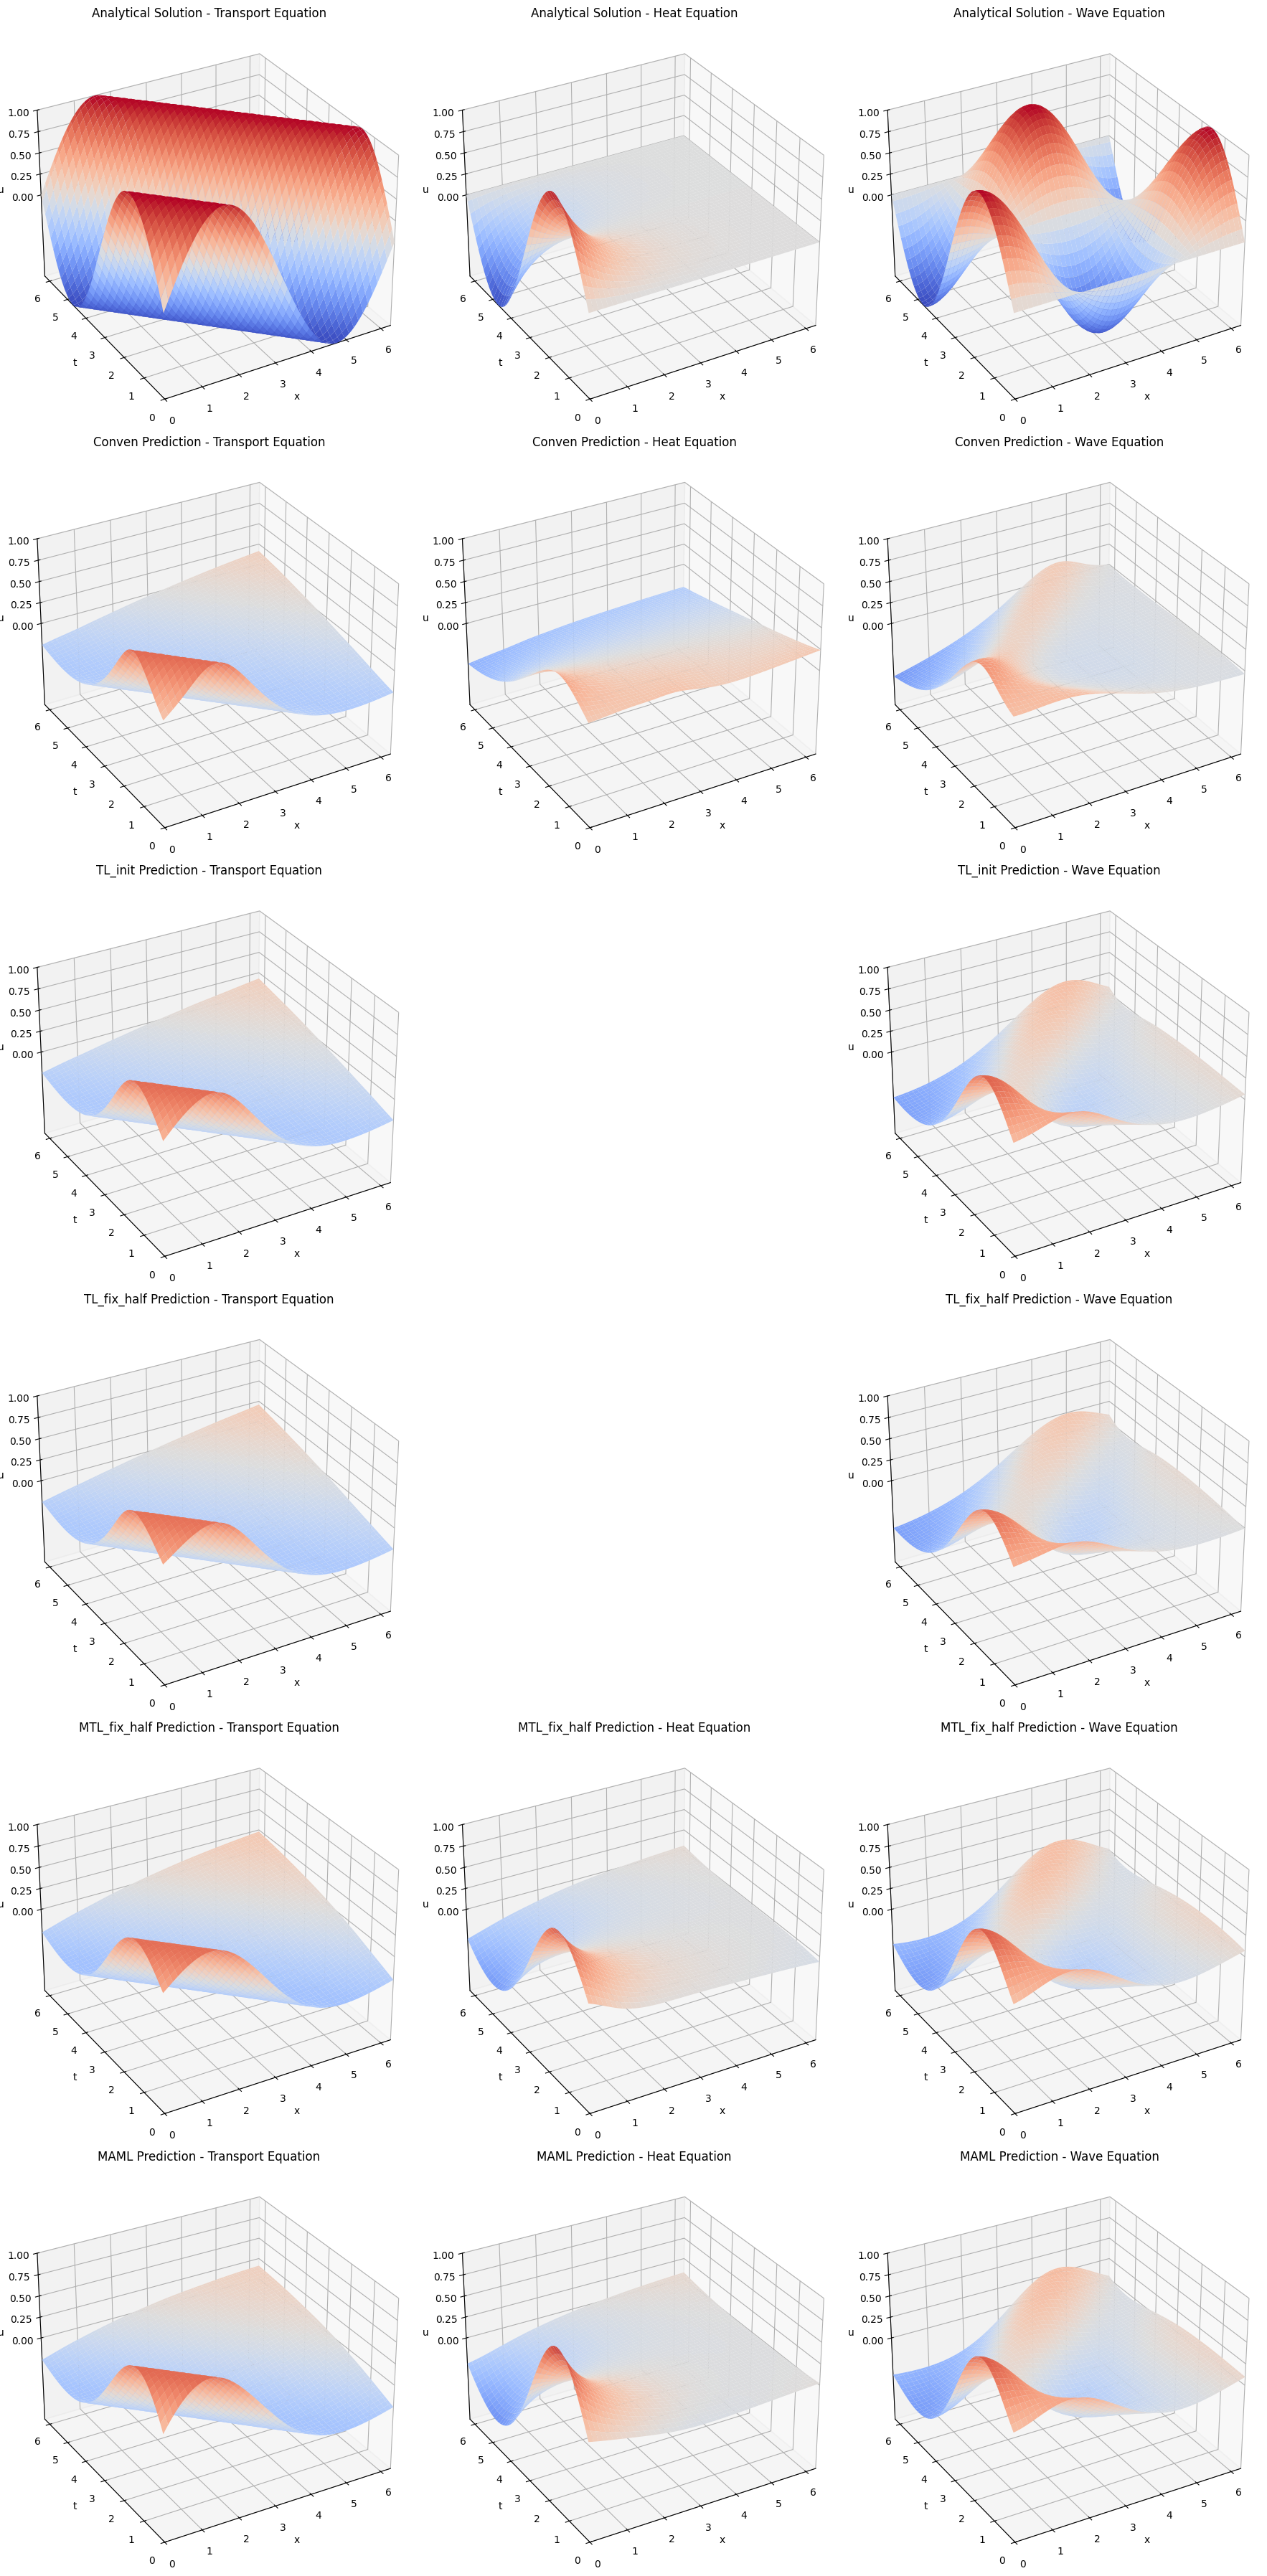

In [15]:
fig = plt.figure(figsize=(col_n * 6, row_n * 6))
for i, (solution, title) in enumerate(solutions, start=1):
    if title in ["TL_init Prediction - Heat Equation","TL_fix_half Prediction - Heat Equation"]:
        continue

    ax = fig.add_subplot(row_n, col_n, i, projection='3d')
    ax.plot_surface(x_grid.numpy(), t_grid.numpy(), solution, cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    ax.set_zlabel('u')
    ax.view_init(elev=30, azim=-120)
    ax.set_xlim(0, 2 * np.pi)
    ax.set_ylim(0, 2 * np.pi)
    ax.set_zlim(-1, 1)
    ax.set_zticks([0, 0.25, 0.5, 0.75, 1])

plt.tight_layout()
plt.show()

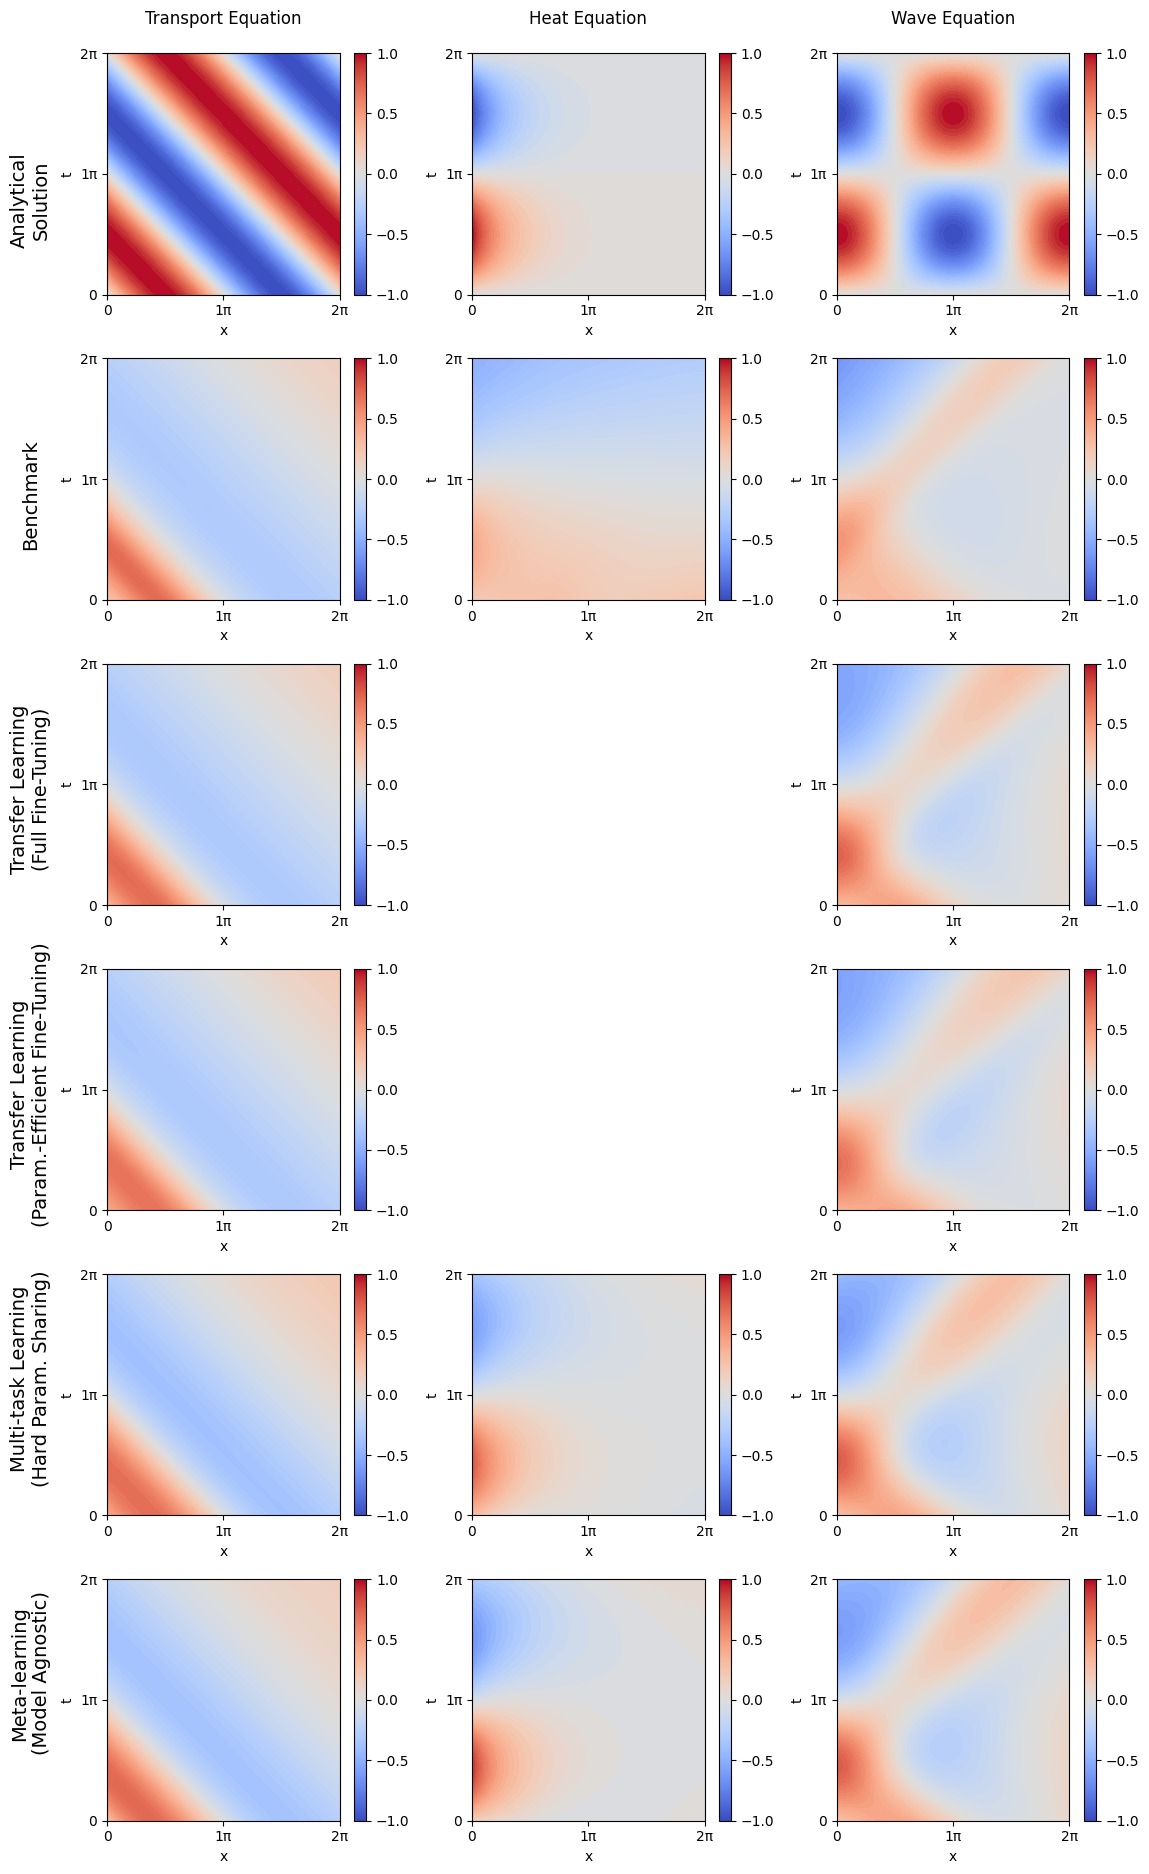

In [16]:
fig = plt.figure(figsize=(col_n * 4, row_n * 3.14))

# Add row titles
row_titles = ["Analytical\nSolution", "Benchmark", "Transfer Learning\n(Full Fine-Tuning)", "Transfer Learning\n(Param.-Efficient Fine-Tuning)", "Multi-task Learning\n(Hard Param. Sharing)", "Meta-learning\n(Model Agnostic)"]
for i, row_title in enumerate(row_titles, start=1):
    plt.text(
        x=-0.075,  # Position to the left of the plot
        y=1 - (i - 0.5) / row_n,
        s=row_title,
        fontsize=14,
        va='center',
        ha='center',
        rotation='vertical'
    )
    plt.axis('off')




# Loop through each subplot
for i, (solution, title) in enumerate(solutions, start=1):
    if title in ["TL_init Prediction - Heat Equation", "TL_fix_half Prediction - Heat Equation"]:
        continue


    ax = fig.add_subplot(row_n, col_n, i)
    cont = ax.contourf(x_grid, t_grid, solution, levels=50, cmap='coolwarm', vmin=-1, vmax=1)
    fig.colorbar(plt.cm.ScalarMappable(norm=cont.norm, cmap=cont.cmap), ax=ax, ticks=[-1, -0.5, 0, 0.5, 1])
    #ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    ax.xaxis.set_major_formatter(tck.FuncFormatter(
        lambda val,pos: '{:.0g}π'.format(val/np.pi) if val !=0 else '0'
        ))
    ax.xaxis.set_major_locator(tck.MultipleLocator(base=np.pi))

    ax.yaxis.set_major_formatter(tck.FuncFormatter(
        lambda val,pos: '{:.0g}π'.format(val/np.pi) if val !=0 else '0'
        ))
    ax.yaxis.set_major_locator(tck.MultipleLocator(base=np.pi))

    
    if i<=3:
        ax.set_title(['Transport Equation\n', 'Heat Equation\n', 'Wave Equation\n'][i-1])

plt.tight_layout()
plt.show()

### Relative $L_2$

In [125]:
def relative_l2_loss(analytical, predicted):
    return np.linalg.norm(analytical - predicted) / np.linalg.norm(analytical)

In [128]:
L2_df = pd.DataFrame()
L2_df[''] = ['transport', 'heat', 'wave']

L2_df['conventional'] = [relative_l2_loss(transport_solution, transport_pred),
                            relative_l2_loss(heat_solution, heat_pred),
                            relative_l2_loss(wave_solution, wave_pred)]

L2_df['TL_init'] = [relative_l2_loss(transport_solution, TL_init_transport_pred), '',
                         #relative_l2_loss(heat_solution, TL_init_heat_pred),
                         relative_l2_loss(wave_solution, TL_init_wave_pred)]

# L2_df['TL_fix_last'] = [relative_l2_loss(transport_solution, TL_fix_last_transport_pred), '',
#                          #relative_l2_loss(heat_solution, TL_fix_last_heat_pred),
#                          relative_l2_loss(wave_solution, TL_fix_last_wave_pred)]

L2_df['TL_fix_half'] = [relative_l2_loss(transport_solution, TL_fix_half_transport_pred), '',
                         #relative_l2_loss(heat_solution, TL_fix_half_heat_pred),
                         relative_l2_loss(wave_solution, TL_fix_half_wave_pred)]

# L2_df['MTL_fix_last'] = [relative_l2_loss(transport_solution, MTL_fix_last_transport_pred),
#                          relative_l2_loss(heat_solution, MTL_fix_last_heat_pred),
#                          relative_l2_loss(wave_solution, MTL_fix_last_wave_pred)]

L2_df['MTL_fix_half'] = [relative_l2_loss(transport_solution, MTL_fix_half_transport_pred),
                         relative_l2_loss(heat_solution, MTL_fix_half_heat_pred),
                         relative_l2_loss(wave_solution, MTL_fix_half_wave_pred)]


L2_df['MAML'] = [relative_l2_loss(transport_solution, meta_transport_pred),
                         relative_l2_loss(heat_solution, meta_heat_pred),
                         relative_l2_loss(wave_solution, meta_wave_pred)]

display(L2_df)

,,conventional,TL_init,TL_fix_half,MTL_fix_half,MAML
0,transport,0.930367,0.919958,0.923275,0.901174,0.892851
1,heat,0.857899,,,0.318607,0.258559
2,wave,0.891601,0.83528,0.861003,0.781816,0.792200


In [131]:
print(L2_df.to_latex())

\begin{tabular}{llrllrr}
\toprule
 &  & conventional & TL_init & TL_fix_half & MTL_fix_half & MAML \\
\midrule
0 & transport & 0.930367 & 0.919958 & 0.923275 & 0.901174 & 0.892851 \\
1 & heat & 0.857899 &  &  & 0.318607 & 0.258559 \\
2 & wave & 0.891601 & 0.835280 & 0.861003 & 0.781816 & 0.792200 \\
\bottomrule
\end{tabular}

